In [10]:
import wandb
import pandas as pd
import numpy as np
import seaborn as sns

from matplotlib import pyplot as plt
%matplotlib inline

In [11]:
api = wandb.Api()

In [12]:
runs = api.runs(path="harvardml/opt-olmo")

In [13]:
optimizers = ['sgdw', 'adamw', 'novagradw_ours', 'adafactorw', 'lionw', 'signsgd',  'sophiag',] 
display_names = ['SGD', 'Adam',  'NovoGrad', 'Adafactor', 'Lion', 'Sign SGD', 'Sophia G',]
colors = sns.color_palette('Set2', n_colors=len(optimizers))

color_map = dict(zip(optimizers, colors))
name_map = dict(zip(optimizers, display_names))

In [14]:
df = pd.DataFrame()

steps = [100, 300, 500, 900, 1700, 2900, 4900, 8500, 14600, 25000]
step = 50000
groups = ["momentum-300-tied-1" , "momentum-300-1"]

for run in runs:
    if run.group in groups:
        history = run.history(samples=50000, 
                        keys=[
                            "eval/c4_val/CrossEntropyLoss", 
                            "train/CrossEntropyLoss", 
                            "optim/total_grad_norm",
                            ])
    
        run_dict = {}
        run_dict["id"] = run.id
        run_dict["name"] = run.name
        run_dict["group"] = run.group
        run_dict["optimizer"] = run.config["optimizer"]["name"]
        run_dict["learning_rate"] = run.config["optimizer"]["learning_rate"]
        run_dict["beta_0"] = run.config["optimizer"]["beta_0"]
        run_dict["beta_1"] = run.config["optimizer"]["beta_1"]
        run_dict["eps"] = run.config["optimizer"]["eps"]
        if "eval/c4_val/CrossEntropyLoss" in history:
            if step not in list(history["_step"]):
                run_dict["val_loss"] = 10.0
            else:
                run_dict["val_loss"] = list(history[history["_step"] == step]["eval/c4_val/CrossEntropyLoss"])[0]
                run_dict["step"] = step
        else:
            run_dict["val_loss"] = np.nan
            run_dict["step"] = np.nan
        if run_dict["optimizer"] == "novagradw" and run.config["optimizer"]["att_correction"]:
            run_dict["optimizer"] = "novagradw_ours"
        if (run_dict["optimizer"] == "adafactorw" and 
            "neuron_only" in run.config["optimizer"] and
            run.config["optimizer"]["neuron_only"]
        ):
            run_dict["optimizer"] = "adafactorw_oneside"
        run_df = pd.DataFrame(run_dict, index=[0])
        df = pd.concat([df, run_df])

In [15]:
df.sort_values("optimizer", inplace=True)

In [16]:
df

,id,name,group,optimizer,learning_rate,beta_0,beta_1,eps,val_loss,step
0,d6jkzci3,olmo_33522783_30,momentum-300-1,adafactorw,0.003160,0.50,0.95,1.000000e-15,2.909706,50000.0
0,h9mg4vz2,olmo_33539319_10,momentum-300-tied-1,adafactorw,0.003160,0.80,0.95,1.000000e-15,2.919207,50000.0
0,4nbrckps,olmo_33539319_12,momentum-300-tied-1,adafactorw,0.003160,0.95,0.95,1.000000e-15,2.903817,50000.0
0,thc5p2xb,olmo_33539319_9,momentum-300-tied-1,adafactorw,0.003160,0.50,0.95,1.000000e-15,3.014472,50000.0
0,qozs5mcx,olmo_33522783_35,momentum-300-1,adafactorw,0.003160,0.99,0.95,1.000000e-15,10.000000,NaN
...,...,...,...,...,...,...,...,...,...,...
0,ymf6f18u,olmo_33522783_20,momentum-300-1,signsgd,0.000316,0.98,0.95,1.000000e-15,2.897055,50000.0
0,n3njztl3,olmo_33517220_21,momentum-300-1,signsgd,0.000316,0.99,0.95,1.000000e-15,NaN,NaN
0,7t8pz1f8,olmo_33522783_15,momentum-300-1,signsgd,0.000316,0.00,0.95,1.000000e-15,3.494305,50000.0
0,daciz74n,olmo_33517220_20,momentum-300-1,signsgd,0.000316,0.98,0.95,1.000000e-15,NaN,NaN


In [17]:
len(df)

113

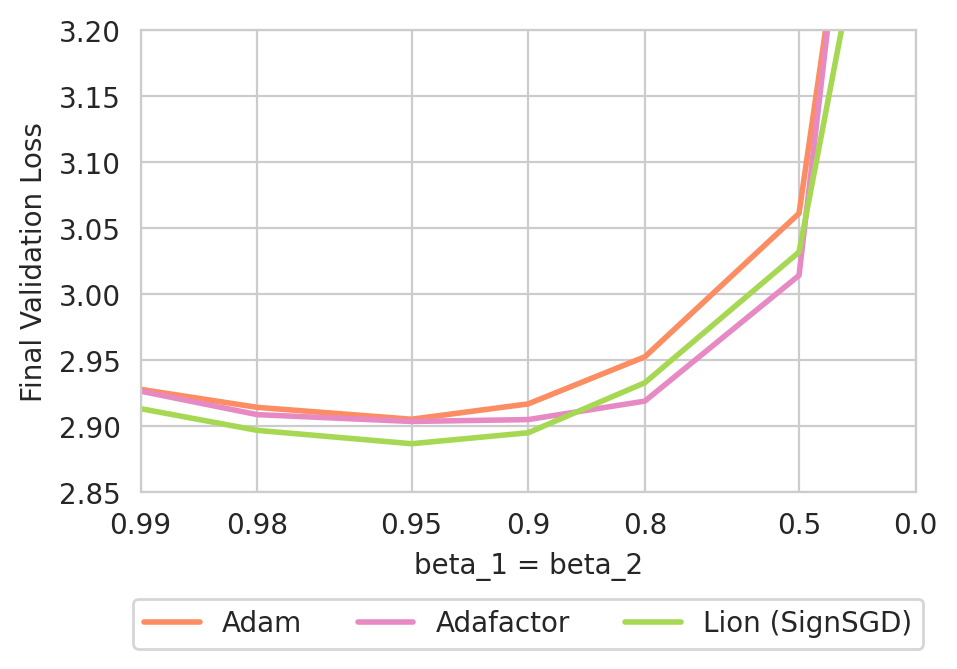

In [18]:
sns.set_style("whitegrid")
plt.figure(figsize=(5, 3), dpi=200)  # Larger figure size

group_df = df

for optimizer in optimizers:
    if optimizer not in ['adamw', 'adafactorw', 'signsgd']:
        continue
    if optimizer == "signsgd":
        group_df = df[df["group"] == "momentum-300-1"]
    else:
        group_df = df[df["group"] == "momentum-300-tied-1"]
    
    if optimizer in group_df["optimizer"].unique():
        optimizer_df = group_df[group_df["optimizer"] == optimizer]
        optimizer_df = optimizer_df.sort_values(by="beta_0")
        optimizer_df = optimizer_df.groupby("beta_0").min().reset_index()
        label = name_map.get(optimizer)
        if optimizer in ["signsgd"]:
            label = "Lion (SignSGD)"
            optimizer = 'lionw'
        plt.plot(1 - optimizer_df["beta_0"], 
                optimizer_df["val_loss"], 
                label=label,
                linewidth=2,
                color=color_map[optimizer],
                # linestyle='--' if optimizer in ['adamw', 'sgdw'] else '-'
        )
        # if optimizer in ["lionw"]:
        #     optimizer_df = df[(df["group"] == "beta-all-1") & (df["optimizer"] == "lionw")]
        #     optimizer_df = optimizer_df.sort_values(by="beta_1")
        #     optimizer_df = optimizer_df.groupby("beta_1").min().reset_index()
        #     label = "Lion (beta 2)"
        #     plt.plot(1 - optimizer_df["beta_1"], 
        #             optimizer_df["val_loss"], 
        #             label=label,
        #             linewidth=2,
        #             color=color_map["lionw"],
        #             linestyle=':',
        #     )


plt.xscale("log")
plt.ylim(2.85, 3.2)
plt.xlim(0.01, 1)

plt.xlabel("beta_1 = beta_2")
xs = [0.0, 0.5, 0.8, 0.9, 0.95, 0.98, 0.99][::-1]

xsa = 1 - np.array(xs)
plt.xticks(xsa, xs)
plt.ylabel("Final Validation Loss")
plt.title("300m (standard)")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=False, ncol=len(optimizers))
plt.show()